<a href="https://colab.research.google.com/github/parmatma25/Brain-tumor-detector/blob/main/Brain_Tumor_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
! unzip "archive.zip"

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_0712.jpg  
  inflating: Training/glioma/Tr-gl_0713.jpg  
  inflating: Training/glioma/Tr-gl_0714.jpg  
  inflating: Training/glioma/Tr-gl_0715.jpg  
  inflating: Training/glioma/Tr-gl_0716.jpg  
  inflating: Training/glioma/Tr-gl_0717.jpg  
  inflating: Training/glioma/Tr-gl_0718.jpg  
  inflating: Training/glioma/Tr-gl_0719.jpg  
  inflating: Training/glioma/Tr-gl_0720.jpg  
  inflating: Training/glioma/Tr-gl_0721.jpg  
  inflating: Training/glioma/Tr-gl_0722.jpg  
  inflating: Training/glioma/Tr-gl_0723.jpg  
  inflating: Training/glioma/Tr-gl_0724.jpg  
  inflating: Training/glioma/Tr-gl_0725.jpg  
  inflating: Training/glioma/Tr-gl_0726.jpg  
  inflating: Training/glioma/Tr-gl_0727.jpg  
  inflating: Training/glioma/Tr-gl_0728.jpg  
  inflating: Training/glioma/Tr-gl_0729.jpg  
  inflating: Training/glioma/Tr-gl_0730.jpg  
  inflating: Training/glioma/Tr-gl_0731.jpg  
  inflating: Training/glioma/

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt

In [6]:
# Define paths and parameters
TRAINING_DIR = "Training" # Your main unzipped directory for training
VALIDATION_DIR = "Testing" # Use your testing/validation directory
IMG_HEIGHT = 150 # Standard image size for input
IMG_WIDTH = 150
BATCH_SIZE = 32
NUM_CLASSES = 4 # Adjust this based on your actual number of tumor types + 'normal'

# 2.1. Instantiate Data Augmentation and Preprocessing Generators
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to 0-1
    rotation_range=20, # Data augmentation
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255) # Only rescale for validation data

# 2.2. Load Data from Directories
train_generator = train_datagen.flow_from_directory(
    TRAINING_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical' # Use 'binary' for 2 classes, 'categorical' for > 2 classes
)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [7]:
model = Sequential([
    # Convolutional Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2, 2),

    # Convolutional Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Convolutional Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Flattening and Dense Layers
    Flatten(),
    Dropout(0.5), # Regularization to prevent overfitting
    Dense(512, activation='relu'),

    # Output Layer
    # Use 'softmax' for multi-class, 'sigmoid' for binary classification
    Dense(NUM_CLASSES, activation='softmax')
])

# 3.1. Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Use 'binary_crossentropy' for 2 classes
    metrics=['accuracy']
)

# Print a summary of the model structure
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,716 (72.62 MB)

 Trainable params: 19,035,716 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS = 20 # You may need to run more epochs (e.g., 50-100) to reach 90%

print("Starting model training...")

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Training finished.")

Starting model training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 50s 244ms/step - accuracy: 0.3944 - loss: 1.3983 - val_accuracy: 0.5234 - val_loss: 1.3397
Epoch 2/20
  1/178 ━━━━━━━━━━━━━━━━━━━━ 8:47 3s/step - accuracy: 0.5625 - loss: 0.9570

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5625 - loss: 0.9570 - val_accuracy: 0.4984 - val_loss: 1.3397
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - accuracy: 0.6394 - loss: 0.8583 - val_accuracy: 0.5523 - val_loss: 1.2170
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6250 - loss: 0.9353 - val_accuracy: 0.4906 - val_loss: 1.5460
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 234ms/step - accuracy: 0.6948 - loss: 0.7306 - val_accuracy: 0.7297 - val_loss: 0.6703
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6562 - loss: 0.7625 - val_accuracy: 0.7203 - val_loss: 0.6858
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 43s 240ms/step - accuracy: 0.7326 - loss: 0.6977 - val_accuracy: 0.6898 - val_loss: 0.7950
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8750 - loss: 0.4580 - val_accuracy: 0.7156 - val_loss: 0.7071
Epoch 9/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 233ms/step - accuracy: 0.7435 - loss: 0.6452 - val_accurac

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.7420 - loss: 0.6131
Final Validation Loss: 0.6544
Final Validation Accuracy: 74.07%


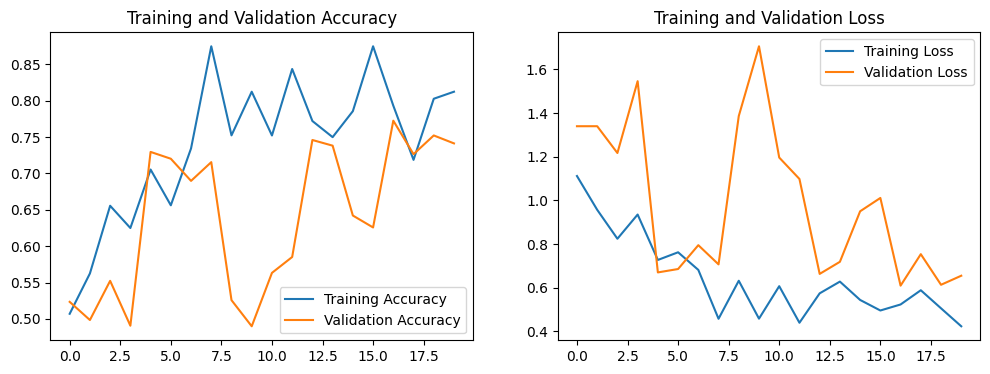

Model saved as brain_tumor_classifier.h5


In [9]:
# 5.1. Final Evaluation
loss, accuracy = model.evaluate(validation_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")

# 5.2. Plotting Accuracy and Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# 5.3. Save the trained model
model.save("brain_tumor_classifier.h5")
print("Model saved as brain_tumor_classifier.h5")

In [10]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16 # Import the pre-trained model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Define parameters (same as before)
TRAINING_DIR = "Training"
VALIDATION_DIR = "Testing"
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
NUM_CLASSES = 4 # Adjust this based on your actual class count

In [11]:
# 2.1. Instantiate Data Augmentation and Preprocessing Generators
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255) # Only rescale for validation

# 2.2. Load Data from Directories
train_generator = train_datagen.flow_from_directory(
    TRAINING_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [12]:
# 3.1. Load the Pre-trained VGG16 Model
# weights='imagenet': Use weights pre-trained on the ImageNet dataset
# include_top=False: Exclude the final classification layer of VGG16
# input_shape: Must match the input shape of your images
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# 3.2. Freeze the Base Model Layers
# This prevents the pre-trained weights from being updated during training.
# They act as a fixed feature extractor.
base_model.trainable = False

# 3.3. Build the New Classification Head
model = Sequential([
    base_model, # The frozen VGG16 model

    Flatten(), # Flatten the output of the VGG16 convolutional layers

    Dense(512, activation='relu'),
    Dropout(0.5), # Regularization

    Dense(NUM_CLASSES, activation='softmax') # Our new classification layer
])

# 3.4. Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,911,556 (72.14 MB)

 Trainable params: 4,196,868 (16.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [13]:
EPOCHS = 10 # Start with fewer epochs; transfer learning often converges faster

print("Starting model training with VGG16 Transfer Learning...")

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Training finished.")

# 4.1. Final Evaluation
loss, accuracy = model.evaluate(validation_generator)
print(f"Final Validation Loss (Transfer Learning): {loss:.4f}")
print(f"Final Validation Accuracy (Transfer Learning): {accuracy*100:.2f}%")

# 4.2. Save the trained model
model.save("brain_tumor_vgg16_classifier.h5")
print("Model saved as brain_tumor_vgg16_classifier.h5")

Starting model training with VGG16 Transfer Learning...
Epoch 1/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 65s 310ms/step - accuracy: 0.5970 - loss: 1.1617 - val_accuracy: 0.7594 - val_loss: 0.6696
Epoch 2/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8438 - loss: 0.4883 - val_accuracy: 0.7469 - val_loss: 0.6891
Epoch 3/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 46s 260ms/step - accuracy: 0.7648 - loss: 0.6034 - val_accuracy: 0.7836 - val_loss: 0.5875
Epoch 4/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7500 - loss: 0.6827 - val_accuracy: 0.7844 - val_loss: 0.5881
Epoch 5/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 47s 262ms/step - accuracy: 0.7947 - loss: 0.5230 - val_accuracy: 0.8203 - val_loss: 0.4876
Epoch 6/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8438 - loss: 0.4547 - val_accuracy: 0.8195 - val_loss: 0.4896
Epoch 7/10
178/178 ━━━━━━━━━━━━━━━━━━━━ 82s 461ms/step - accuracy: 0.7957 - loss: 0.5281 - val_accuracy: 0.8328 - val_loss: 0.4639
Epoch 8/10
178/178 ━━━━━━━━━━━━━━

Final Validation Loss (Transfer Learning): 0.4086
Final Validation Accuracy (Transfer Learning): 84.06%
Model saved as brain_tumor_vgg16_classifier.h5


In [15]:
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import tensorflow as tf

# Load the best model saved from the previous steps
# Adjust the filename if you saved it differently
best_model = tf.keras.models.load_model('brain_tumor_vgg16_fine_tuned.h5')

# The validation_generator (or testing_generator) must be reset for proper evaluation
validation_generator.reset()

# 1.1. Get True Labels and Predictions
print("Generating predictions on the validation set...")
Y_pred = best_model.predict(validation_generator)
y_pred_classes = np.argmax(Y_pred, axis=1) # Convert probabilities to class indices
y_true = validation_generator.classes # Get the true class indices

# 1.2. Get Class Labels (Names)
# This mapping is created by flow_from_directory
class_labels = list(validation_generator.class_indices.keys())
print(f"Class Labels: {class_labels}")

# 1.3. Compute the Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

print("\nConfusion Matrix:\n", conf_matrix)

# 1.4. Plotting Function for better visualization
#
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(conf_matrix, classes=class_labels, title='Brain Tumor Confusion Matrix')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'brain_tumor_vgg16_fine_tuned.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [16]:
!ls

archive.zip		   brain_tumor_vgg16_classifier.h5  Testing
brain_tumor_classifier.h5  sample_data			    Training


Loading model: brain_tumor_vgg16_classifier.h5
Generating predictions on the validation set...
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 178ms/step

Confusion Matrix (Raw Counts):
 [[ 61  66  90  83]
 [ 65  53 108  80]
 [ 79  84 136 106]
 [ 62  53  99  86]]
Confusion matrix, without normalization


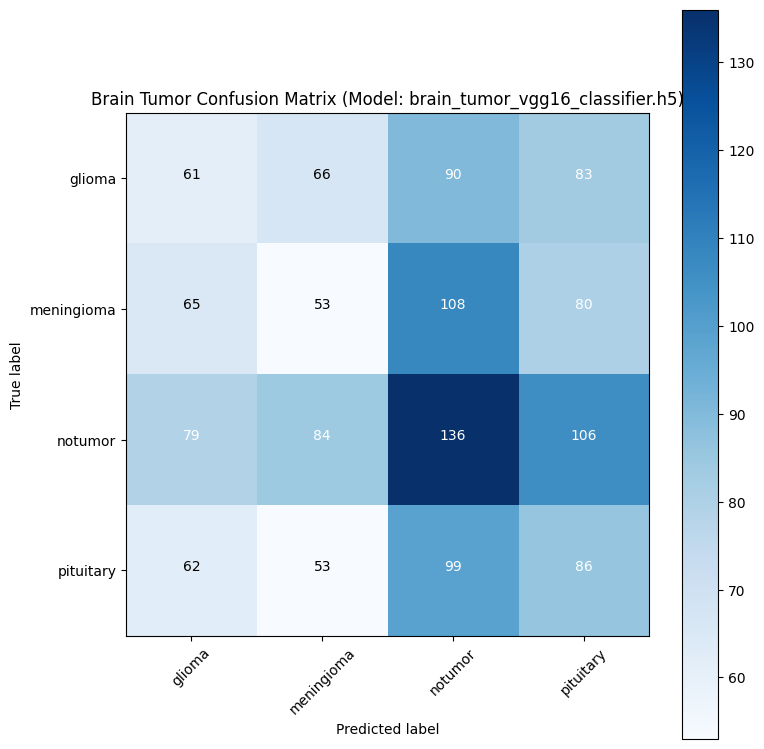

Normalized confusion matrix


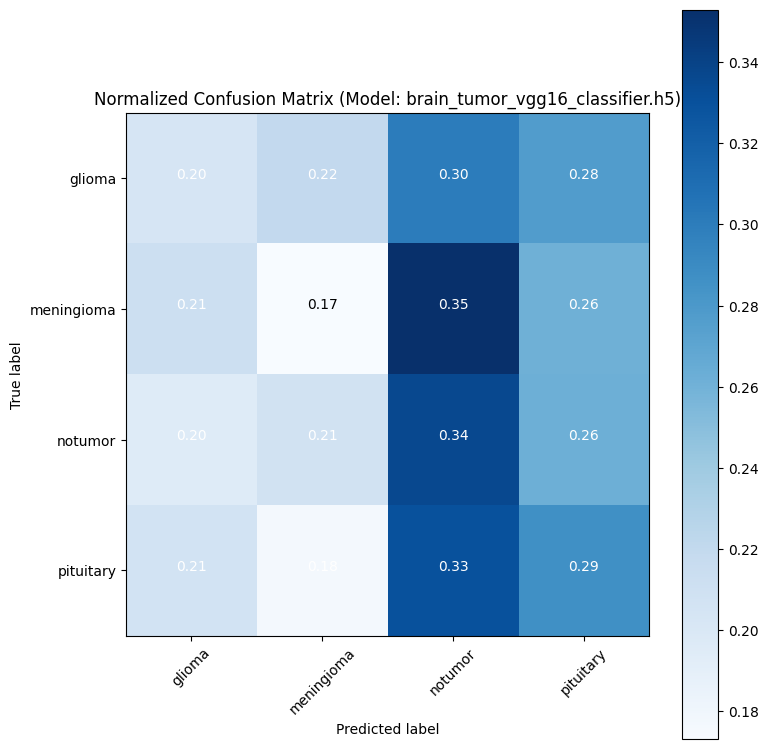

In [17]:
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model # Import the load_model function

# --- Configuration (Ensure these match your training setup) ---
# Replace 'your_actual_file_name.h5' with the name confirmed by !ls
MODEL_FILENAME = 'brain_tumor_vgg16_classifier.h5'
BATCH_SIZE = 32
# -----------------------------------------------------------

## 1. Load the Model
print(f"Loading model: {MODEL_FILENAME}")
try:
    best_model = load_model(MODEL_FILENAME)
except Exception as e:
    print(f"Error loading model: {e}")
    # Handle the error, perhaps by stopping execution
    exit()

## 2. Prepare Data for Prediction
# The validation_generator (or testing_generator) must be reset
# to ensure predictions align with the true labels (y_true).
validation_generator.reset()

# Get True Labels and Class Names
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

## 3. Generate Predictions
print("Generating predictions on the validation set...")
steps = validation_generator.samples // BATCH_SIZE
if validation_generator.samples % BATCH_SIZE != 0:
    steps += 1 # Ensure all samples are predicted

Y_pred = best_model.predict(validation_generator, steps=steps)
y_pred_classes = np.argmax(Y_pred, axis=1) # Convert probabilities to class indices

## 4. Compute and Plot the Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
print("\nConfusion Matrix (Raw Counts):\n", conf_matrix)

# Plotting Function for better visualization
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    """Prints and plots the confusion matrix."""
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Plot the confusion matrix (without normalization)
plot_confusion_matrix(conf_matrix, classes=class_labels, title=f'Brain Tumor Confusion Matrix (Model: {MODEL_FILENAME})')

# Plot the normalized confusion matrix (shows percentages)
plot_confusion_matrix(conf_matrix, classes=class_labels, normalize=True, title=f'Normalized Confusion Matrix (Model: {MODEL_FILENAME})')

Loaded Class Labels: ['glioma', 'meningioma', 'notumor', 'pituitary']
Loading model: brain_tumor_vgg16_classifier.h5 for prediction.


Please upload a test image file (e.g., a single MRI scan).


Saving Brain tumors.jpeg to Brain tumors.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


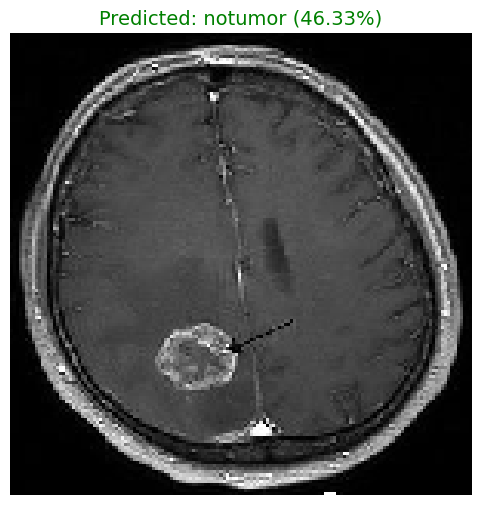

------------------------------
✅ Prediction Result: *notumor*
Confidence: *46.33%*
------------------------------
Full Probability Vector (for debugging):
  glioma: 18.60%
  meningioma: 24.99%
  notumor: 46.33%
  pituitary: 10.08%


In [18]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

# --- Configuration (Based on your setup) ---
MODEL_FILENAME = 'brain_tumor_vgg16_classifier.h5'
IMG_HEIGHT = 150
IMG_WIDTH = 150
# NOTE: The class_labels list must be defined based on your ImageDataGenerator output
# For example, if you have 4 classes:
# class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
# You can redefine this list based on the output from the confusion matrix step.
try:
    # Assuming you still have the validation_generator defined from the previous steps
    class_labels = list(validation_generator.class_indices.keys())
    print(f"Loaded Class Labels: {class_labels}")
except NameError:
    # Fallback if validation_generator is no longer defined (replace with your actual classes)
    print("Warning: validation_generator not found. Using dummy class labels.")
    class_labels = ['Class_A', 'Class_B', 'Class_C', 'Class_D']
# -----------------------------------------------------------

## 2. Load the Model
print(f"Loading model: {MODEL_FILENAME} for prediction.")
try:
    best_model = load_model(MODEL_FILENAME)
except Exception as e:
    print(f"Error: Could not load model file '{MODEL_FILENAME}'. Ensure it is in the current directory.")
    print(f"Details: {e}")
    exit()


# 2.1. Helper function for prediction
def predict_uploaded_image(model, img_path, class_labels, img_height, img_width):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array /= 255.0 # Rescale to match training data (CRUCIAL step)

    # Make prediction
    predictions = model.predict(img_array)

    # Get the class and confidence
    predicted_class_index = np.argmax(predictions[0])
    predicted_class = class_labels[predicted_class_index]
    confidence = predictions[0][predicted_class_index] * 100

    # Display image and results
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)", fontsize=14, color='green')
    plt.axis('off')
    plt.show()

    print("-" * 30)
    print(f"✅ Prediction Result: *{predicted_class}*")
    print(f"Confidence: *{confidence:.2f}%*")
    print("-" * 30)
    print("Full Probability Vector (for debugging):")
    for label, prob in zip(class_labels, predictions[0]):
        print(f"  {label}: {prob*100:.2f}%")


# 2.2. Upload the file and test
print("Please upload a test image file (e.g., a single MRI scan).")
uploaded = files.upload()

for fn in uploaded.keys():
    # Run the prediction
    predict_uploaded_image(
        model=best_model,
        img_path=fn,
        class_labels=class_labels,
        img_height=IMG_HEIGHT,
        img_width=IMG_WIDTH
    )